# Global Economic & Electricity Trends: Dimensionality Reduction with PCA and SVD

**Datasets:**
- World GDP — 179 countries × 52 years (1970–2021)
- US Electricity Sales — 62 states × 24 years (2001–2024)

**Objective:** Explore how much of the variance in large economic time-series datasets can be captured by a small number of principal components, and reconstruct individual country/state series using those components.

**Methods:** Manual PCA via eigendecomposition of the covariance matrix; SVD directly on the standardised data matrix. Both approaches compared for accuracy and efficiency.

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA

## 1. Global GDP Dataset

**Source:** World GDP data, 179 countries, 1970–2021 (52 years).

Standardise across years so each country's values are expressed in standard deviations from its own historical mean — this centres the series and removes scale differences between economies.

In [ ]:
data_raw = pd.read_csv("data/domestic_product.csv", index_col=0)
data_raw.head(10)

In [ ]:
data_raw.shape

(179, 52)

### 1.1 GDP Time Series by Country

In [ ]:
def plot_gdp_time_series(df, countries):
    """
    Plots time-series GDP data for each specified country in separate subplots.

    Parameters:
    df (pd.DataFrame): The GDP dataframe with countries as rows and years as columns.
    countries (list): List of countries to plot.

    Returns:
    None
    """

    # Extract the data for the specified countries
    data = df.loc[countries]

    # Set up the figure and subplots
    fig, axes = plt.subplots(len(countries), 1, figsize=(10, 15), sharex=True)
    fig.suptitle("GDP Time Series for Selected Countries (Original Data)")

    # Plot each country's time-series in a separate subplot
    for i, country in enumerate(countries):
        axes[i].plot(data.columns, data.loc[country], label=country)
        axes[i].set_title(country)
        axes[i].set_ylabel("GDP")
        axes[i].legend()

    # Rotate x-axis labels for all subplots using plt.xticks()
    plt.xticks(rotation=45, ha='right')

    plt.xlabel("Year")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

### 1.2 Standardisation

In [ ]:
scaler = StandardScaler()

# Transpose the dataframe, apply the scaler, and transpose back
standardized_df = pd.DataFrame(scaler.fit_transform(data_raw.T).T, index=data_raw.index, columns=data_raw.columns)

# Now `standardized_df` contains the standardized GDP data

In [ ]:
print(standardized_df.head())

                  1970      1971      1972      1973      1974      1975  \
 Country                                                                   
Afghanistan  -0.833578 -0.820925 -0.846562 -0.838042 -0.782239 -0.742133   
Albania      -0.755018 -0.741864 -0.728319 -0.714354 -0.700094 -0.685304   
Algeria      -1.244898 -1.241549 -1.212438 -1.179466 -1.114746 -1.077878   
Andorra      -1.288180 -1.277327 -1.253176 -1.215526 -1.179598 -1.145842   
Angola       -0.763397 -0.758717 -0.756506 -0.735166 -0.720910 -0.755449   

                  1976      1977      1978      1979  ...      2012      2013  \
 Country                                              ...                       
Afghanistan  -0.712005 -0.657392 -0.601742 -0.538355  ...  1.871779  1.947212   
Albania      -0.670000 -0.654824 -0.638327 -0.733422  ...  1.279374  1.371743   
Algeria      -1.042637 -0.990592 -0.904150 -0.794505  ...  2.028626  2.044685   
Andorra      -1.138628 -1.111755 -1.057411 -0.953267  ...  1.1

### 1.3 Original vs Standardised GDP

Original Data:


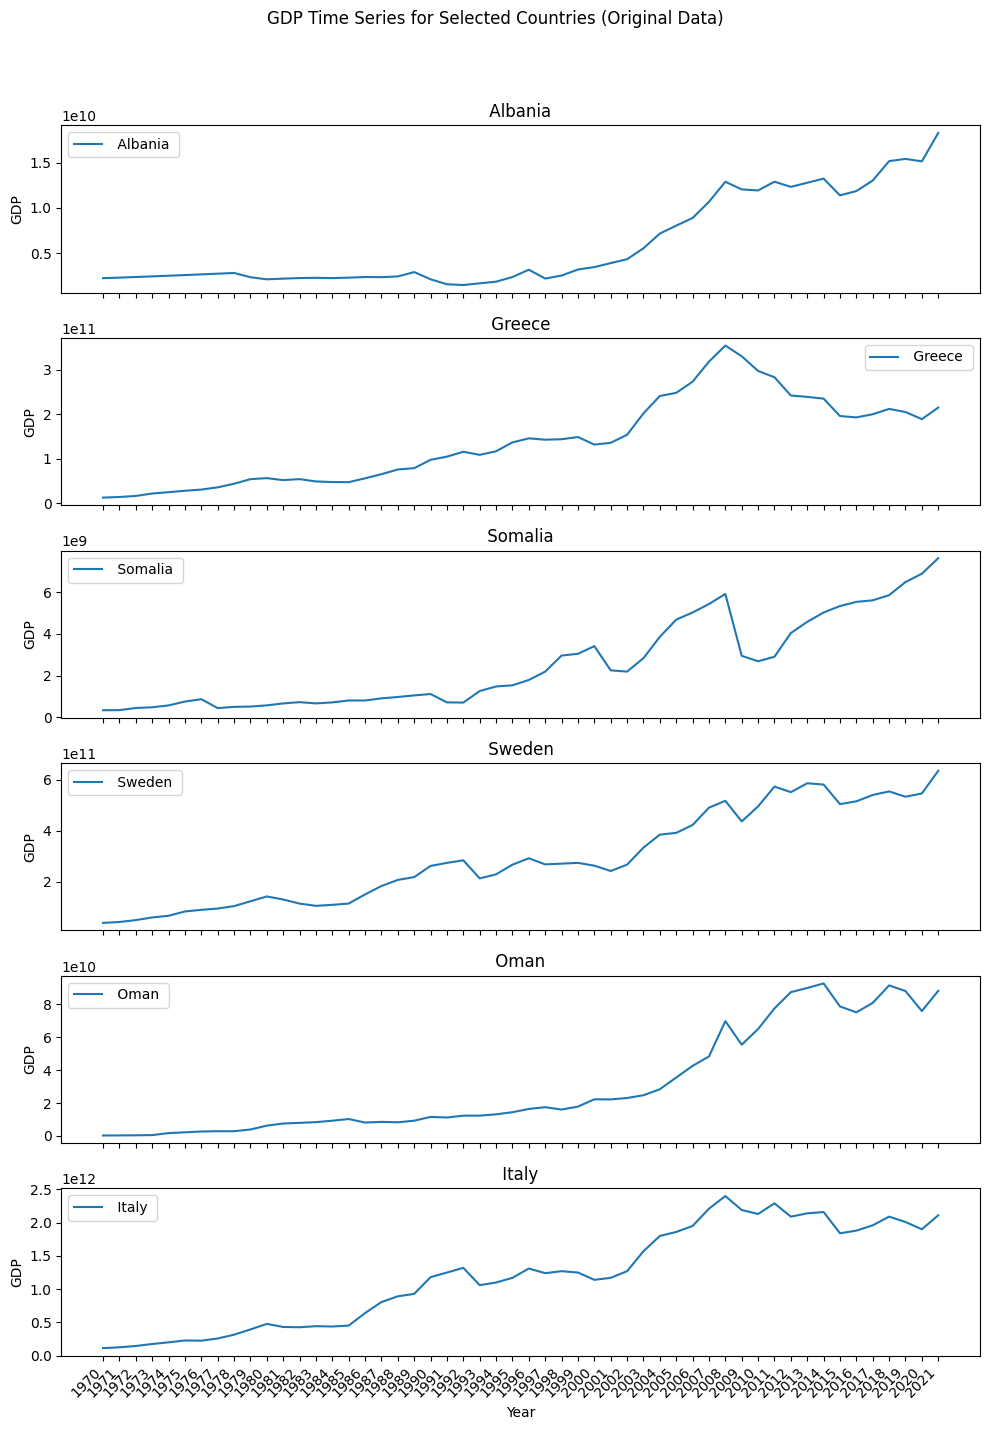

Standardized Data:


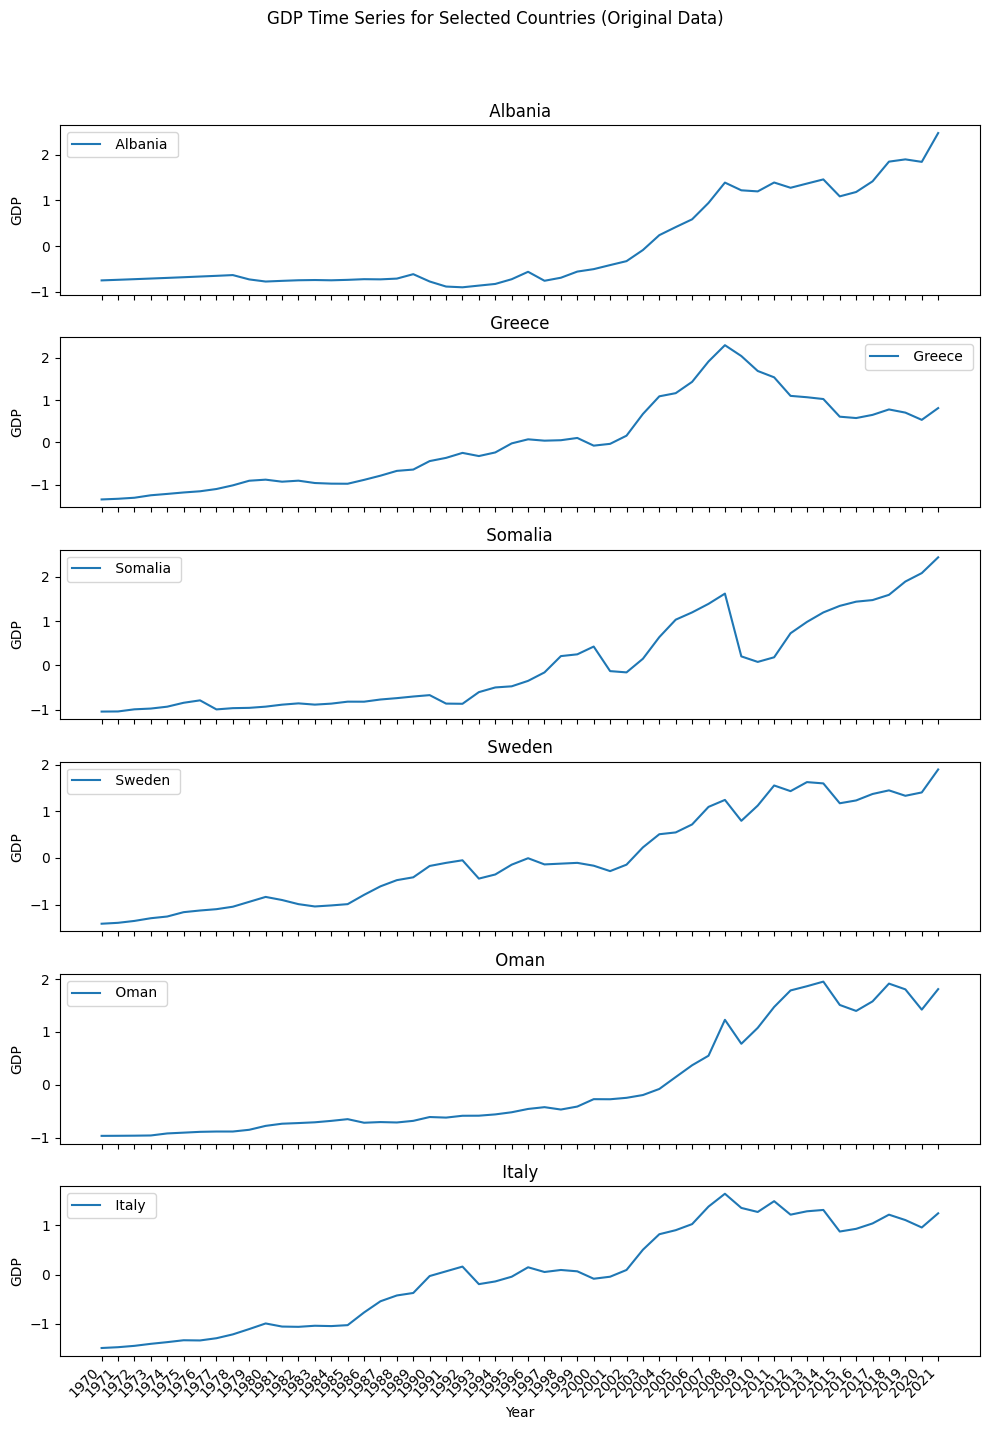

In [ ]:
# List of countries to analyze
countries_to_analyze = [' Albania ', ' Greece ', ' Somalia ', ' Sweden ', ' Oman ',  ' Italy ']

# Plotting original data
print("Original Data:")
plot_gdp_time_series(data_raw, countries_to_analyze)

# Plotting standardized data
print("Standardized Data:")
plot_gdp_time_series(standardized_df, countries_to_analyze)

### 1.4 Trend Analysis

Discuss the trends in the standardized time-series for Albania,Greece,Somalia,Sweden,Oman, and Italy. What does it mean if the curve goes up or down? What does the sign of values indicate? [0.5]

Analysis of Country's Standardized Data Trends:

Overall, all countries have experienced GDP growth between 1970 to 2021
All countries experienced a downward trend in GDP growth in 2008, likely caused by the US housing market crash and subsequent economic impacts. Most of the countries seem to have recovered after 2008.
Greece has seen a consistent YOY downward trend after 2008
Italy has seen plateauing growth after 2008 - the graph of the countries GDP growth shows upward and downward YOY trends that cancel each other out.
Albania, Somalia, Oman, and Sweden are showing very strong upward trends. By 2021, they reached around 2 standard deviations from the mean based on their entire historical data.
Upward Trend:

An upward trend in the standardized time series for a country indicates a period where that country's GDP was increasing relative to its own historical average. This means the country was experiencing above-average GDP growth compared to its entire historical trend.

Downward Trend:

A downward trend reflects a period where that country’s GDP was below its own historical average, meaning slower or negative growth relative to its own past performance. For example, if Greece's curve goes down, it shows that its GDP growth was below Greece’s historical average for that period.

Sign of Values:

Positive values indicate that the GDP for a specific year was above that country’s historical average. Negative values indicate that the GDP for a specific year was below that country’s historical average. For instance, a positive standardized value for Italy in a particular year means Italy’s GDP was above its average GDP for the entire period, while a negative value would mean it was below its average.

## 2. PCA — Global GDP

Apply PCA manually via eigendecomposition of the covariance matrix. Steps: compute covariance → sort eigenpairs → scree plot → variance explained → plot first 16 PCs as time series.

### 2.1 Covariance Matrix

In [ ]:
# Compute the covariance matrix
cov_matrix = data_raw.cov()
print(cov_matrix.shape)  # Should output (52, 52)

(52, 52)


### 2.2 Eigendecomposition

In [ ]:
def get_sorted_eigen(df_cov):
    # Calculate eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(df_cov)

    # Sort them in descending order of eigenvalues
    sorted_indices = np.argsort(eigenvalues)[::-1]
    sorted_eigenvalues = eigenvalues[sorted_indices]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]

    return sorted_eigenvalues, sorted_eigenvectors

# Get sorted eigenvalues and eigenvectors
sorted_eigenvalues, sorted_eigenvectors = get_sorted_eigen(cov_matrix)

### 2.3 Scree Plot

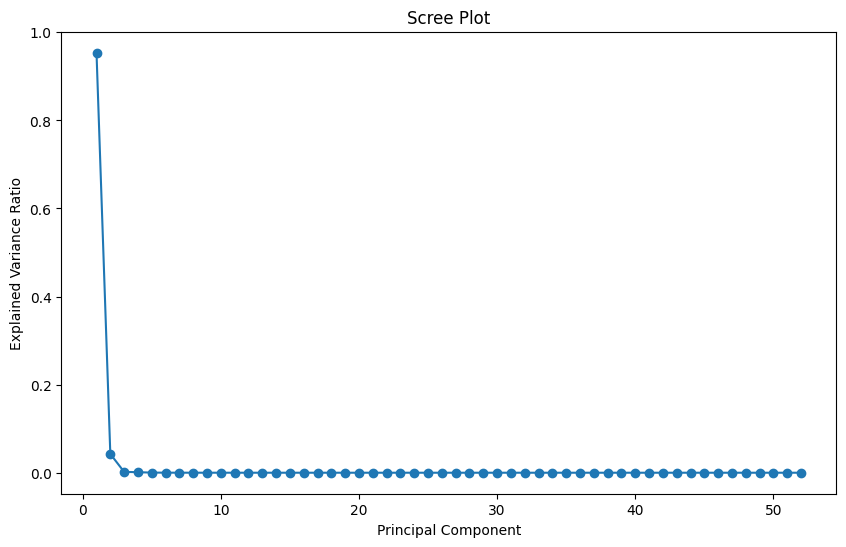

In [ ]:
# Calculate the explained variance ratio
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)

# Plotting the scree plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o')
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.show()

### 2.4 Variance Explained

In [ ]:
# Calculate cumulative explained variance
cumulative_variance = np.cumsum(explained_variance_ratio)

# Find the number of PCs to reach 99.9%
num_pcs_999 = np.argmax(cumulative_variance >= 0.999) + 1
print(f"Number of PCs to cover 99.9% of variance: {num_pcs_999}")

Number of PCs to cover 99.9% of variance: 4


### 2.5 First 16 Principal Components

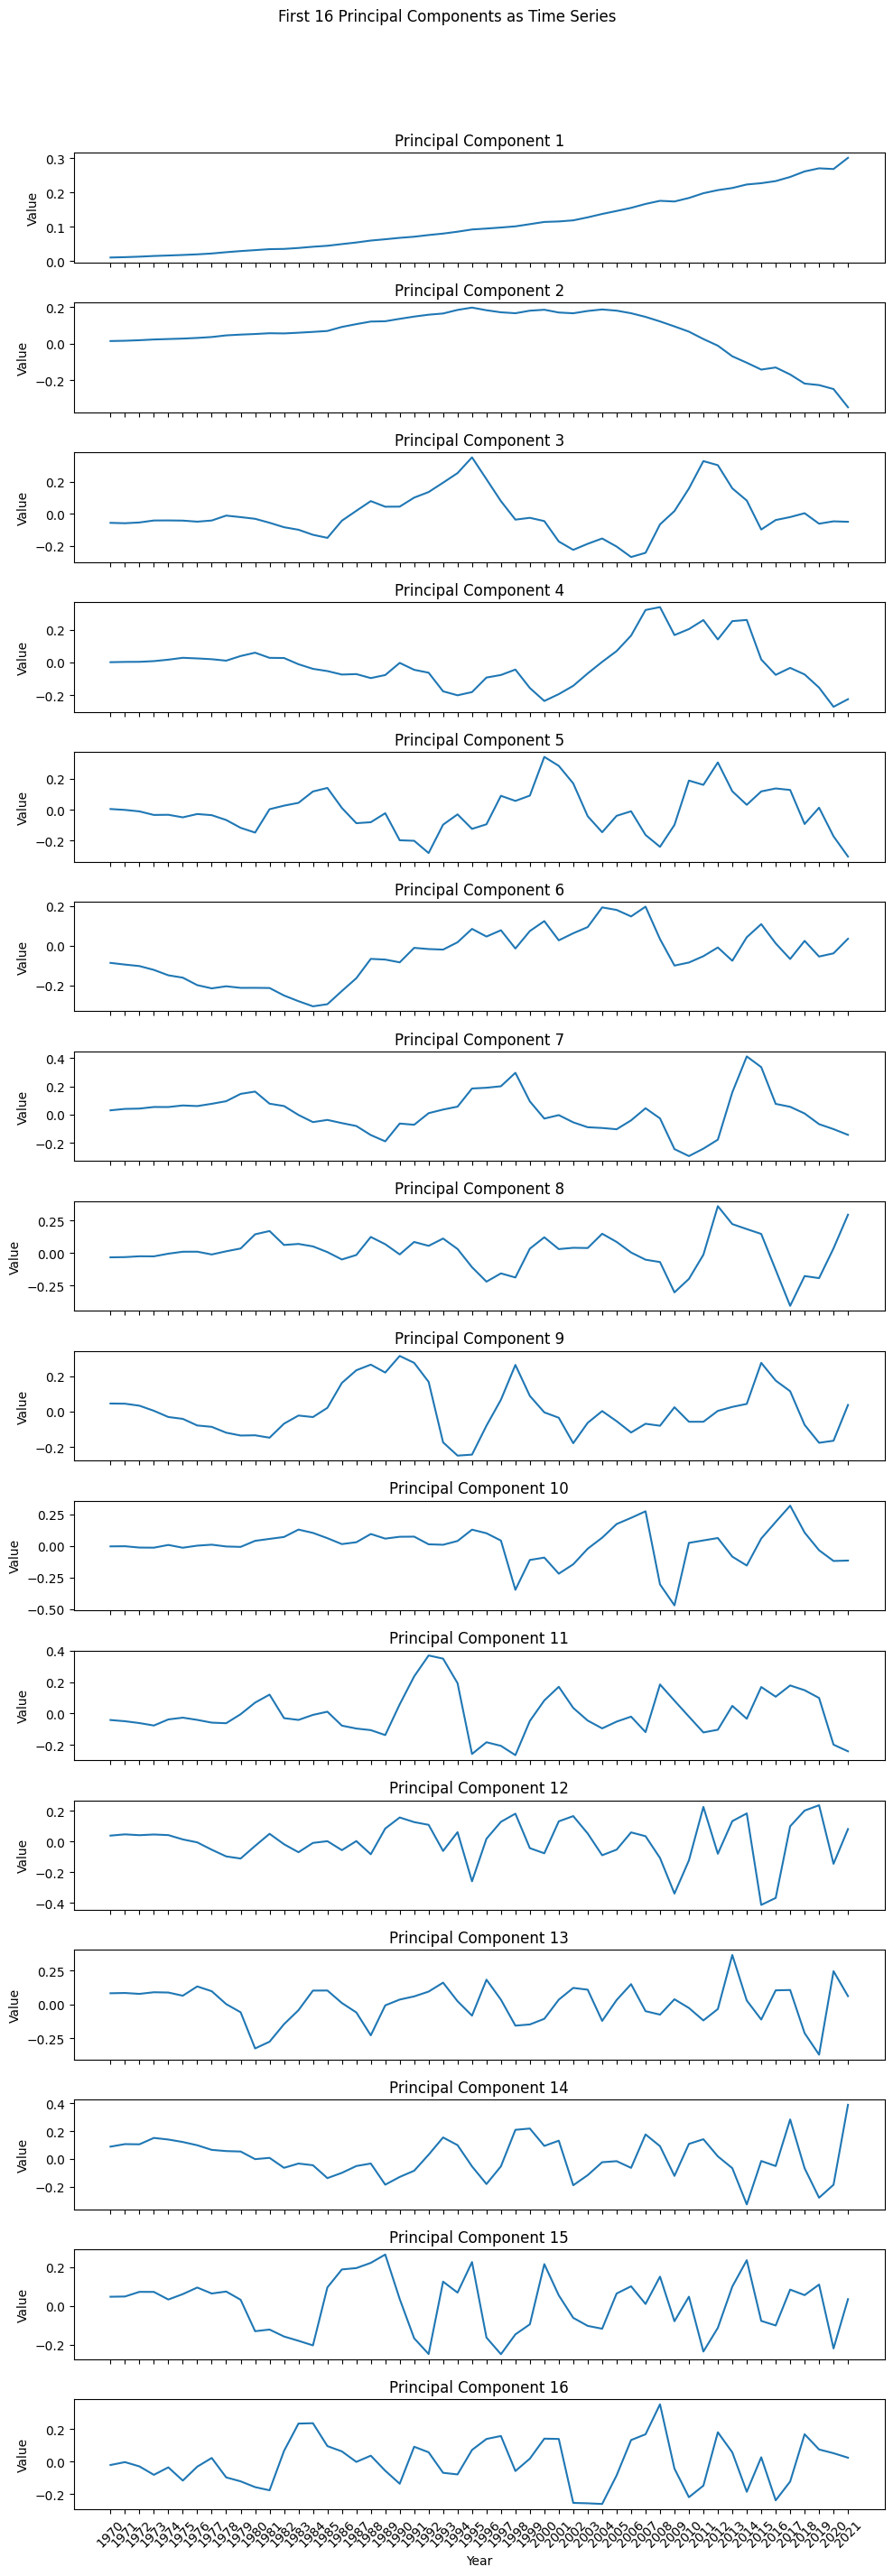

In [ ]:
# Select the first 16 principal components
first_16_pcs = sorted_eigenvectors[:, :16]

# Plot each component in a separate subplot
fig, axes = plt.subplots(16, 1, figsize=(10, 30), sharex=True)
fig.suptitle("First 16 Principal Components as Time Series")

for i in range(16):
    axes[i].plot(data_raw.columns, first_16_pcs[:, i])
    axes[i].set_title(f"Principal Component {i+1}")
    axes[i].set_ylabel("Value")

plt.xlabel("Year")
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Lower-Numbered PCs (e.g., PC1, PC2)**

*   **Global or Dominant Trends:** The first few principal components capture
broad, overarching economic trends that impact most countries in similar ways. For example, PC1 might represent global GDP growth, reflecting a general upward trend that applies to many countries.
*   **Smooth Patterns:** Lower-numbered PCs tend to show smoother, less volatile patterns over time, indicating stable, long-term influences rather than short-term fluctuations. This suggests that these components capture steady trends, like technological progress or industrialization, that drive economic growth globally.
*   **Majority of Variance Explained:** The first few PCs explain the largest portion of the variance in the data, meaning they contain the most significant information. By retaining only these components, you capture the essential patterns while simplifying the dataset.
*   **Useful for Dimensionality Reduction:** Retaining only the first few PCs is useful when aiming to understand general trends without needing all the specific details of each country’s economic data.


**Higher-Numbered PCs (e.g., PC3, PC4, onward)**

*   **Country-Specific or Regional Trends**: Higher-numbered PCs capture more nuanced, localized patterns that may apply to specific countries or regions. These could include unique economic events, such as regional recessions, political instability, or industry-specific trends affecting certain countries more than others.
*  **Increased Volatility: **These components tend to show more erratic, year-to-year fluctuations. This increased volatility reflects finer details and short-term events, rather than the stable, long-term trends seen in lower-numbered PCs.
*   **Less Variance Explained:** Higher-numbered PCs explain smaller amounts of variance, meaning they contain less impactful information overall. They capture unique patterns and variations that are not as dominant in the dataset.
*   **Capturing Finer Details:** Including these components adds more details specific to individual countries or regions. This can be useful if the goal is to analyze specific economic fluctuations or minor trends, but it may also introduce noise if the goal is to understand broad, global patterns.


## 3. Data Reconstruction

For each country: plot the original GDP series, then incrementally reconstruct it using 1, 2, 4, 8, and 16 PCs. Show residual error and RMSE vs number of components. Countries analysed: Greece, Somalia, Italy, Albania, Sweden, Oman.

In [ ]:
def plot_country_figures(original_df, country_name, y_label):
    # Step 1: Standardize the dataset
    scaler = StandardScaler()
    standardized_df = pd.DataFrame(scaler.fit_transform(original_df.T).T, index=original_df.index, columns=original_df.columns)

    # Step 2: Extract data for the specified country
    country_data = original_df.loc[country_name].values.reshape(-1, 1)  # Shape (52, 1)
    country_scaler = StandardScaler()
    standardized_country_data = country_scaler.fit_transform(country_data)  # Standardize country data

    # Step 3: Compute the covariance matrix, eigenvalues, and eigenvectors
    cov_matrix = standardized_df.cov()
    eigenvalues, eigenvectors = get_sorted_eigen(cov_matrix)  # Assumes this function is defined

    # Step 4: Plot the original time series for the specified country
    plt.figure(figsize=(15, 10))

    # Plot 1: Original time-series for the specified country
    plt.subplot(2, 2, 1)
    plt.plot(original_df.columns, country_data, label=f"Original {country_name}")
    plt.title(f"Original Time Series for {country_name}")
    plt.xlabel("Year")
    plt.ylabel(y_label)
    plt.xticks(rotation=45)
    plt.legend()

    # Step 5: Incremental Reconstruction of the time-series
    plt.subplot(2, 2, 2)
    num_pcs_list = [1, 2, 4, 8, 16]  # Number of PCs to use for reconstruction

    for num_pcs in num_pcs_list:
        # Use the first `num_pcs` eigenvectors for reconstruction
        selected_eigenvectors = eigenvectors[:, :num_pcs]  # Shape should be (52, num_pcs)

        # Project data onto the selected PCs
        scores = standardized_country_data.T @ selected_eigenvectors  # Shape (1, num_pcs)

        # Reconstruct using the scores and the selected eigenvectors
        reconstruction = scores @ selected_eigenvectors.T  # Shape should be (1, 52)

        # Scale back to the original values
        reconstruction = country_scaler.inverse_transform(reconstruction.T).flatten()  # Shape (52,)

        # Plot the reconstructed series
        plt.plot(original_df.columns, reconstruction, label=f"PC1 to PC{num_pcs}")

    # Plot the original country data in dashed lines for comparison
    plt.plot(original_df.columns, country_data.flatten(), 'k--', label="Original")
    plt.title(f"Incremental Reconstruction for {country_name}")
    plt.xlabel("Year")
    plt.ylabel(y_label)
    plt.legend()
    plt.xticks(rotation=45)

    # Step 6: Plot the residual error for the best reconstruction (e.g., using PC1 to PC16)
    plt.subplot(2, 2, 3)
    best_num_pcs = 16
    selected_eigenvectors = eigenvectors[:, :best_num_pcs]
    scores = standardized_country_data.T @ selected_eigenvectors
    best_reconstruction = scores @ selected_eigenvectors.T
    best_reconstruction = country_scaler.inverse_transform(best_reconstruction.T).flatten()
    residuals = country_data.flatten() - best_reconstruction
    plt.plot(original_df.columns, residuals, label="Residual Error")
    plt.title(f"Residual Error with PC1 to PC{best_num_pcs} Reconstruction")
    plt.xlabel("Year")
    plt.ylabel("Residual Error")
    plt.xticks(rotation=45)
    plt.legend()

    # Step 7: Calculate RMSE as a function of the number of components
    plt.subplot(2, 2, 4)
    rmse_values = []
    for num_pcs in range(1, 11):
        selected_eigenvectors = eigenvectors[:, :num_pcs]
        scores = standardized_country_data.T @ selected_eigenvectors
        reconstruction = scores @ selected_eigenvectors.T
        reconstruction = country_scaler.inverse_transform(reconstruction.T).flatten()
        rmse = np.sqrt(mean_squared_error(country_data.flatten(), reconstruction))
        rmse_values.append(rmse)

    plt.plot(range(1, 11), rmse_values, marker='o')
    plt.title("RMSE vs Number of Components")
    plt.xlabel("Number of Components")
    plt.ylabel("RMSE")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

### 3.1 Country Reconstructions

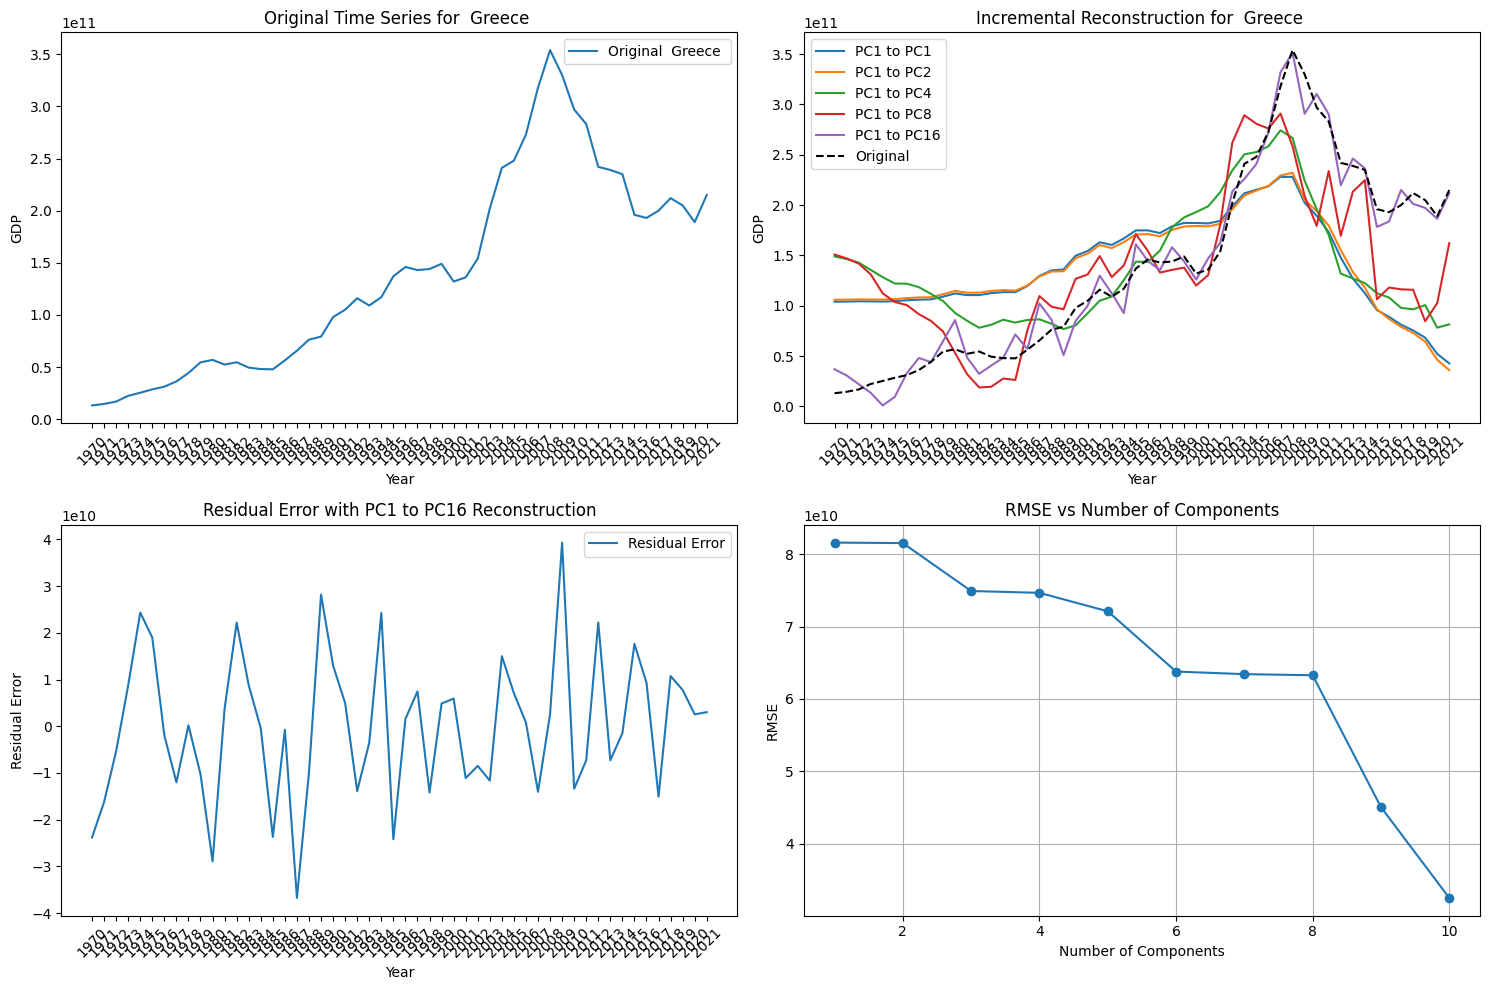

In [ ]:
plot_country_figures(data_raw, ' Greece ', "GDP")

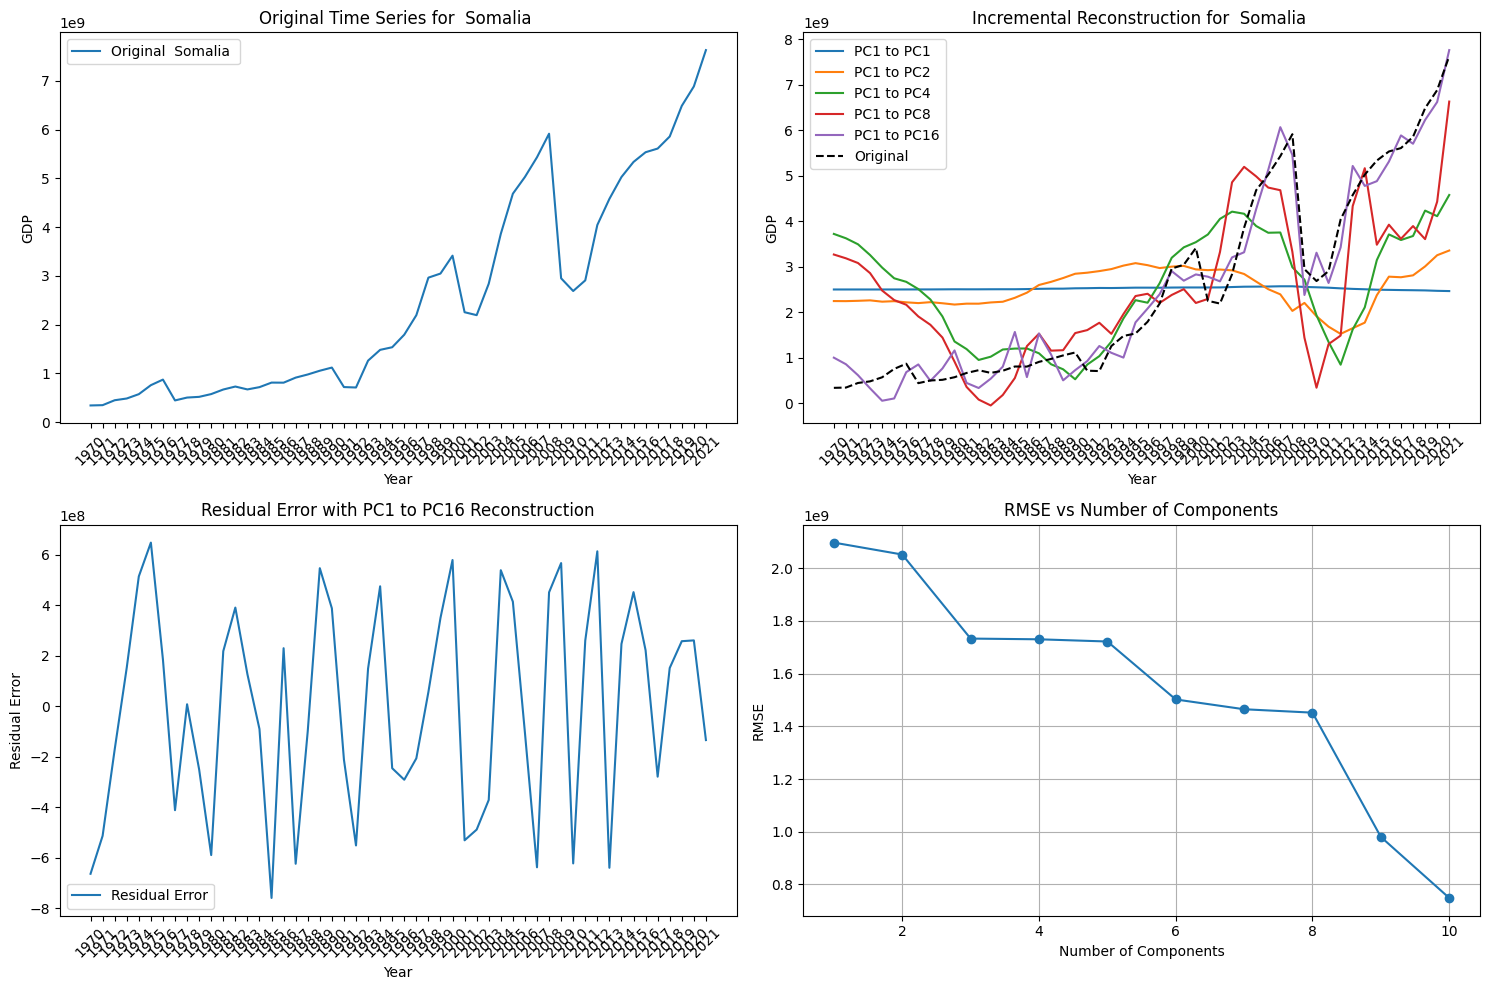

In [ ]:
plot_country_figures(data_raw, ' Somalia ', "GDP")

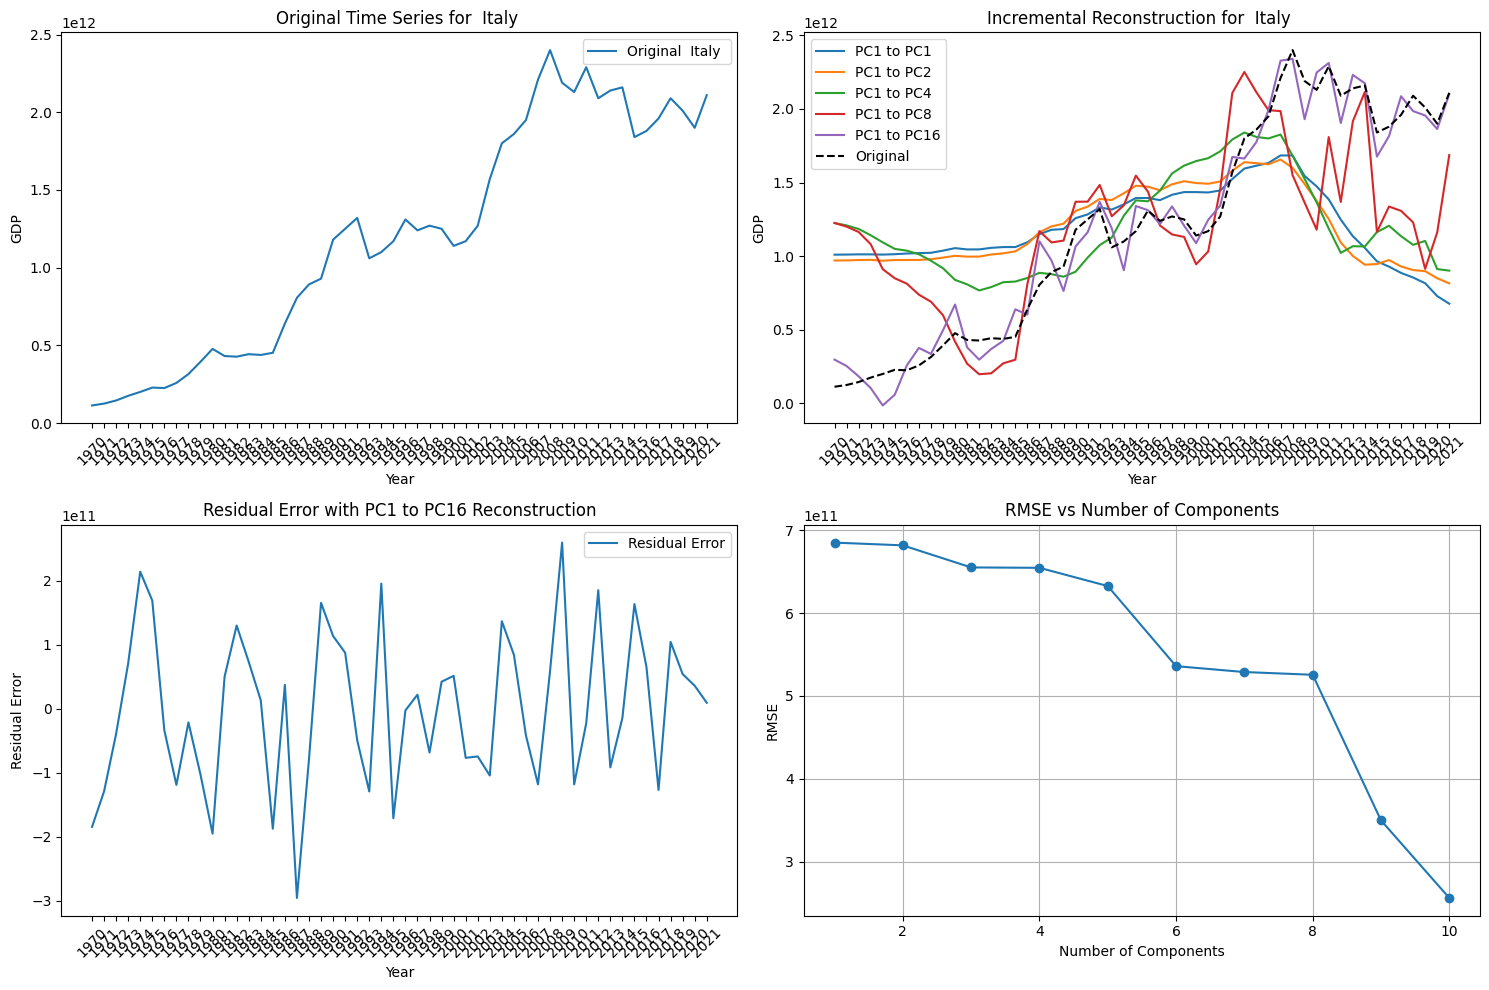

In [ ]:
plot_country_figures(data_raw, ' Italy ', "GDP")

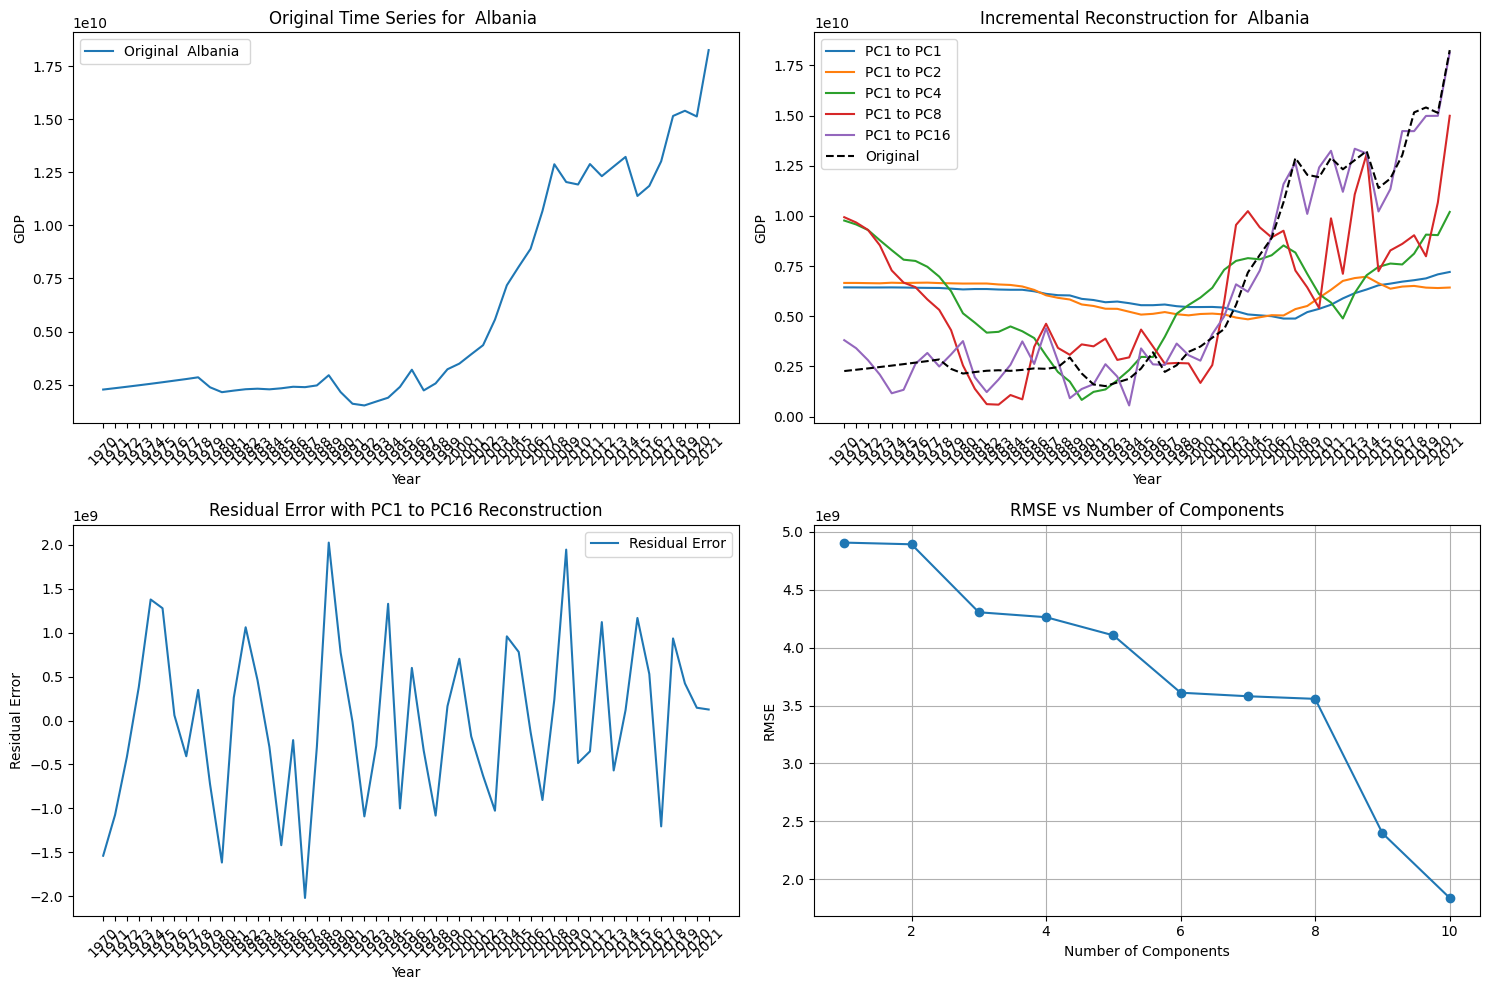

In [ ]:
plot_country_figures(data_raw, ' Albania ', "GDP")

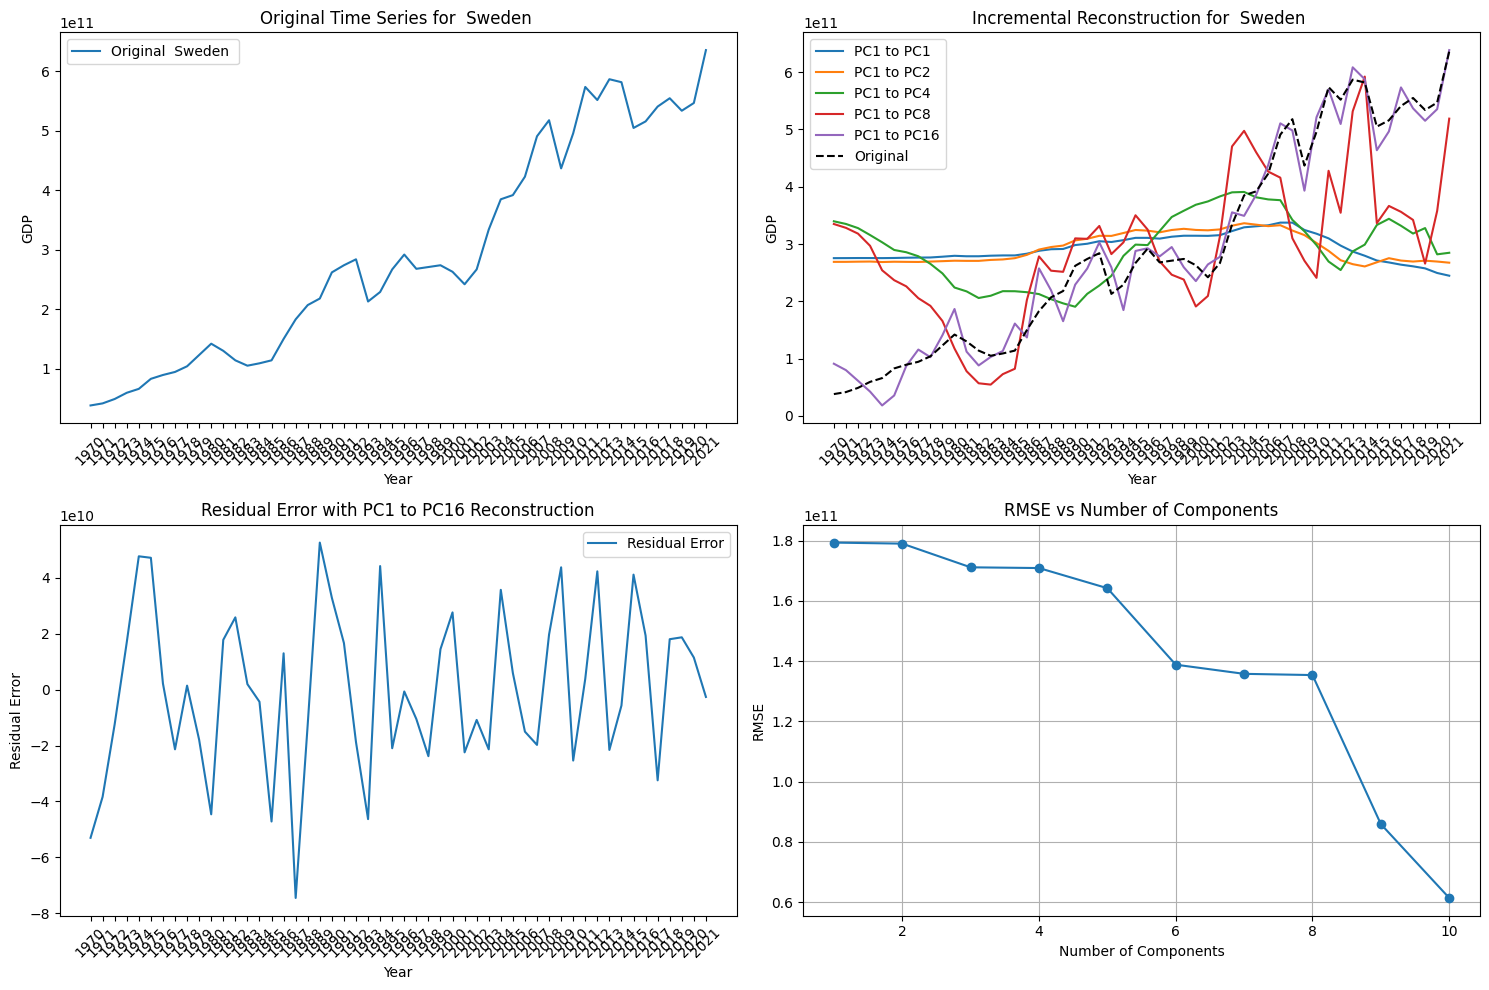

In [ ]:
plot_country_figures(data_raw, ' Sweden ', "GDP")

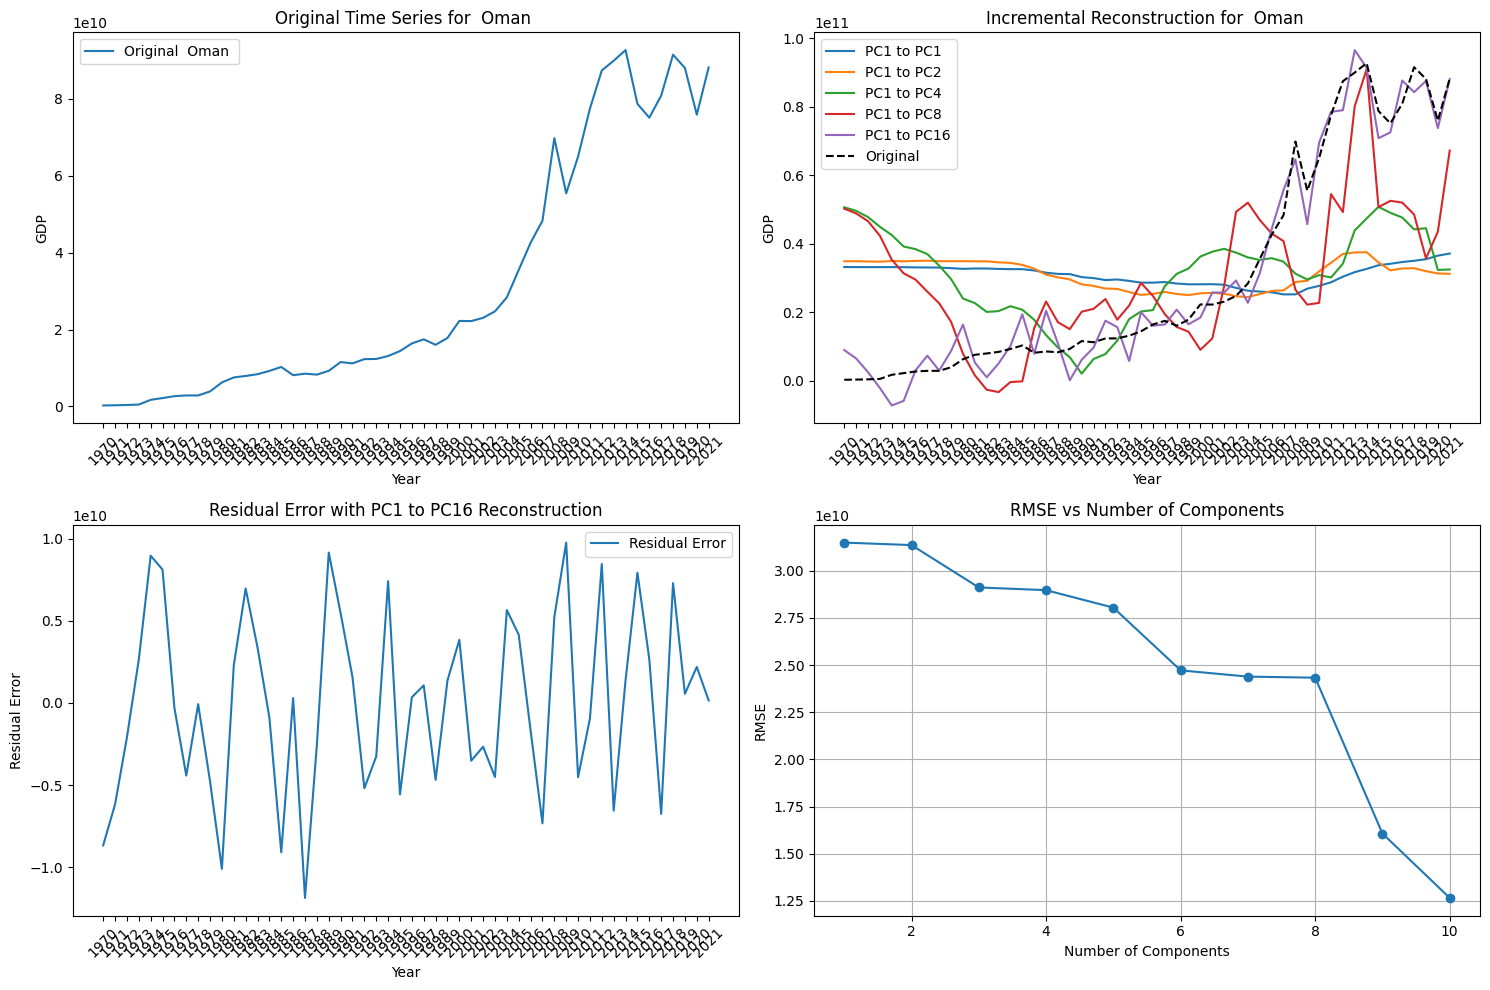

In [ ]:
plot_country_figures(data_raw, ' Oman ', "GDP")

## 4. SVD — Comparison with PCA

Repeat the reconstruction analysis using SVD (`np.linalg.svd`) directly on the standardised data matrix — no covariance computation required. Compare results and runtime against PCA.

In [ ]:
def plot_country_figures_svd(original_df, country_name,y_label):
    # Step 1: Standardize the dataset
    scaler = StandardScaler()
    standardized_df = pd.DataFrame(scaler.fit_transform(original_df.T).T, index=original_df.index, columns=original_df.columns)

    # Step 2: Extract data for the specified country
    country_data = original_df.loc[country_name].values.reshape(-1, 1)  # Shape (52, 1)
    country_scaler = StandardScaler()
    standardized_country_data = country_scaler.fit_transform(country_data)  # Standardize country data

    # Step 3: Perform SVD on the standardized data matrix
    U, S, Vt = np.linalg.svd(standardized_df, full_matrices=False)
    singular_values = S
    eigenvectors = Vt.T  # The columns of Vt.T are the principal components

    # Step 4: Plot the original time series for the specified country
    plt.figure(figsize=(15, 10))

    # Plot 1: Original time-series for the specified country
    plt.subplot(2, 2, 1)
    plt.plot(original_df.columns, country_data, label=f"Original {country_name}")
    plt.title(f"Original Time Series for {country_name}")
    plt.xlabel("Year")
    plt.ylabel(y_label)
    plt.xticks(rotation=45)
    plt.legend()

    # Step 5: Incremental Reconstruction of the time-series
    plt.subplot(2, 2, 2)
    num_pcs_list = [1, 2, 4, 8, 16]  # Number of PCs to use for reconstruction

    for num_pcs in num_pcs_list:
        # Use the first `num_pcs` singular vectors for reconstruction
        selected_eigenvectors = eigenvectors[:, :num_pcs]  # Shape should be (52, num_pcs)

        # Project data onto the selected singular vectors
        scores = standardized_country_data.T @ selected_eigenvectors  # Shape (1, num_pcs)

        # Reconstruct using the scores and the selected singular vectors
        reconstruction = scores @ selected_eigenvectors.T  # Shape should be (1, 52)

        # Scale back to the original values
        reconstruction = country_scaler.inverse_transform(reconstruction.T).flatten()  # Shape (52,)

        # Plot the reconstructed series
        plt.plot(original_df.columns, reconstruction, label=f"PC1 to PC{num_pcs}")

    # Plot the original country data in dashed lines for comparison
    plt.plot(original_df.columns, country_data.flatten(), 'k--', label="Original")
    plt.title(f"Incremental Reconstruction for {country_name} (SVD)")
    plt.xlabel("Year")
    plt.ylabel(y_label)
    plt.legend()
    plt.xticks(rotation=45)

    # Step 6: Plot the residual error for the best reconstruction (e.g., using PC1 to PC16)
    plt.subplot(2, 2, 3)
    best_num_pcs = 16
    selected_eigenvectors = eigenvectors[:, :best_num_pcs]
    scores = standardized_country_data.T @ selected_eigenvectors
    best_reconstruction = scores @ selected_eigenvectors.T
    best_reconstruction = country_scaler.inverse_transform(best_reconstruction.T).flatten()
    residuals = country_data.flatten() - best_reconstruction
    plt.plot(original_df.columns, residuals, label="Residual Error")
    plt.title(f"Residual Error with PC1 to PC{best_num_pcs} Reconstruction (SVD)")
    plt.xlabel("Year")
    plt.ylabel("Residual Error")
    plt.xticks(rotation=45)
    plt.legend()

    # Step 7: Calculate RMSE as a function of the number of components
    plt.subplot(2, 2, 4)
    rmse_values = []
    for num_pcs in range(1, 11):
        selected_eigenvectors = eigenvectors[:, :num_pcs]
        scores = standardized_country_data.T @ selected_eigenvectors
        reconstruction = scores @ selected_eigenvectors.T
        reconstruction = country_scaler.inverse_transform(reconstruction.T).flatten()
        rmse = np.sqrt(mean_squared_error(country_data.flatten(), reconstruction))
        rmse_values.append(rmse)

    plt.plot(range(1, 11), rmse_values, marker='o')
    plt.title("RMSE vs Number of Components (SVD)")
    plt.xlabel("Number of Components")
    plt.ylabel("RMSE")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

**Is Standardization or Covariance Computation Required for SVD?**


*   **Standardization:** Required if features are on different scales. Standardizing ensures each feature contributes equally to the analysis, preventing features with large ranges from dominating the results.
*   **Covariance Computation:** Not required. SVD operates directly on the data matrix, bypassing the need for the covariance matrix. This makes SVD computationally efficient for deriving principal components without this intermediate step.







In [ ]:
def compare_pca_svd(df, entity_name, y_label="Value"):
    print(f"PCA — {entity_name}")
    plot_country_figures(df, entity_name, y_label)
    print(f"SVD — {entity_name}")
    plot_country_figures_svd(df, entity_name, y_label)

compare_pca_svd(data_raw, ' Greece ', "GDP")

**Comments on Results**


**Similar Results:** PCA and SVD show nearly identical results for this analysis because PCA is essentially an SVD of the covariance matrix. In fact, SVD directly on the standardized data matrix achieves the same principal components without explicitly calculating the covariance matrix.

**Speed and Efficiency:** I noticed that the plots for SVD were generated a lot faster suggesting that SVD is computationally more efficient, which is likely because it decomposes the data matrix directly.

**Interpretation:** Both approaches will give similar reconstructions and error profiles since they capture the same underlying structure in the data. I observed this by comparing the incremental reconstructions and RMSE values from both methods.

## 5. US Electricity Sales — PCA & SVD

Second dataset: average monthly electricity sales (MWh) by US state, 2001–2024. Transform the raw data to a state × year matrix, then apply the same PCA and SVD pipeline from Sections 2–4.

In [ ]:
url = "data/electricity_prices.csv"
df = pd.read_csv(url, parse_dates=["date"], index_col="date")
print("Shape:", df.shape)
df.head()

In [ ]:
# Remove rows with any missing values
df_cleaned = df.dropna()

# Display the first few rows of the cleaned DataFrame
print("Cleaned DataFrame (rows with missing values removed):")
print(df_cleaned.head())

# Display the shape of the cleaned DataFrame
print(f"\nCleaned DataFrame shape: {df_cleaned.shape}")

Cleaned DataFrame (rows with missing values removed):
            Unnamed: 0  year  month stateDescription   sectorName  price  \
date                                                                       
2001-01-01           0  2001      1          Wyoming  all sectors   4.31   
2001-01-01           1  2001      1          Wyoming   commercial   5.13   
2001-01-01           2  2001      1          Wyoming   industrial   3.26   
2001-01-01           3  2001      1          Wyoming        other   4.75   
2001-01-01           4  2001      1          Wyoming  residential   6.01   

             revenue       sales  
date                              
2001-01-01  48.12840  1116.17208  
2001-01-01  12.67978   247.08691  
2001-01-01  19.60858   602.30484  
2001-01-01   0.76868    16.17442  
2001-01-01  15.07136   250.60591  

Cleaned DataFrame shape: (85870, 8)


In [ ]:
# Extract the year from the Date column, which is now the index
df['Year'] = df.index.year
# Group by 'State' and 'Year' and calculate the average electricity sales
df_grouped = df.groupby(['stateDescription', 'Year']).agg({'sales': 'mean'}).reset_index()

# Pivot the table so that each state is a row, each year is a column, and values are average electricity sales
df_pivot = df_grouped.pivot(index='stateDescription', columns='Year', values='sales')

# Display the pivoted DataFrame
print("Transformed DataFrame with states as rows and years as columns:")
print(df_pivot)

Transformed DataFrame with states as rows and years as columns:
Year                        2001          2002          2003          2004  \
stateDescription                                                             
Alabama              2645.275267   2768.902600   2794.807334   2895.683966   
Alaska                181.802667    182.182966    185.456066    192.949467   
Arizona              2075.810133   2086.691234   2135.985334   2231.108367   
Arkansas             1391.081634   1414.985267   1436.941967   1455.745333   
California           8258.625933   7840.444400   8107.377200   8400.865767   
...                          ...           ...           ...           ...   
West North Central   8411.670366   8653.042934   8688.918833   8701.003266   
West South Central  16137.869967  16401.395400  16466.390134  16498.878467   
West Virginia         922.314399    948.770734    943.233100    963.953733   
Wisconsin            2173.943100   2233.309867   2241.383134   2265.856967   


In [ ]:
pd.set_option("display.max_columns", None)
print("State × Year electricity sales matrix:")
print(df_pivot.head())

This dataset has 62 cities and 24 features.

In [ ]:
states = ['New York', 'Utah', 'Alaska', 'Arizona', 'Arkansas']
for state in states:
    compare_pca_svd(df_pivot, state, "Avg Monthly Electricity Sales (MWh)")

## Conclusions & Key Findings

**GDP dataset (179 countries, 52 years):**
- Only **4 principal components** capture 99.9% of all variance — global GDP trends are highly correlated across countries
- PC1 represents the broad global growth trend (upward across most countries)
- Higher PCs capture regional or country-specific patterns with increasing volatility
- Reconstruction with 8–16 PCs converges closely to the original series; RMSE drops sharply in the first 3–4 components

**PCA vs SVD:**
- Produce identical principal components (mathematically equivalent)
- SVD is faster: it decomposes the data matrix directly, bypassing covariance computation

**US Electricity dataset:**
- Similar low-rank structure observed — a small number of components captures most state-level variation in electricity sales
- Regional patterns (e.g. seasonal demand in cold vs warm states) emerge in higher PCs

## References

Understanding PCA and SVD:

1. https://towardsdatascience.com/pca-and-svd-explained-with-numpy-5d13b0d2a4d8

2. https://stats.stackexchange.com/questions/134282/relationship-between-svd-and-pca-how-to-use-svd-to-perform-pca

3. https://stats.stackexchange.com/questions/2691/making-sense-of-principal-component-analysis-eigenvectors-eigenvalues

4. https://hadrienj.github.io/posts/Deep-Learning-Book-Series-2.8-Singular-Value-Decomposition/

PCA:

1. Snippets from: https://plot.ly/ipython-notebooks/principal-component-analysis/

2. https://www.value-at-risk.net/principal-component-analysis/

U.S. Electricity Prices Data:

1. https://www.kaggle.com/datasets/alistairking/electricity-prices
